In [ ]:
# TAREA:
# EXPLORANDO TRANSFORMERS EN TEXTO, AUDIO Y VISIÓN
#
# Nombre del alumno:
# Matrícula:
# Fecha:
#
# OBJETIVO:
#
# Aplicar conceptos vistos en clase sobre Transformers mediante tres casos:
#
# 1. Texto con BERT/BETO.
# 2. Audio con Whisper.
# 3. Imagen con un mini Vision Transformer.
#
# INSTRUCCIONES:
#
# - Completa las celdas marcadas como ACTIVIDAD.
# - Explica tus resultados en las celdas de reflexión.
# - No basta con ejecutar código: debes interpretar lo que ocurre.
# - Comenta cualquier modificación que hagas.
#
# FECHA DE ENTREGA:
# 20 de Mayo del año en curso

In [ ]:
# CELDA 1: INSTALACIÓN

!pip install -q transformers
!pip install -q datasets
!pip install -q librosa
!pip install -q soundfile
!pip install -q accelerate

In [ ]:
# CELDA 2: IMPORTS GENERALES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import librosa
import librosa.display

from IPython.display import Audio, display
from google.colab import files

from transformers import AutoTokenizer
from transformers import AutoModelForMaskedLM
from transformers import WhisperProcessor
from transformers import WhisperForConditionalGeneration

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

Dispositivo: cpu


In [ ]:
# PARTE 1:
# PREGUNTAS CONCEPTUALES
#
# Responde con tus propias palabras.

## Pregunta 1

¿Qué problema resolvió Transformer respecto a RNN, LSTM y GRU?

Respuesta:


## Pregunta 2

Explica la fórmula de self-attention:

\[
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

Incluye qué representan Q, K y V.

Respuesta:


## Pregunta 3

Explica la diferencia entre:

- encoder-only
- decoder-only
- encoder-decoder

Da un ejemplo de modelo para cada caso.

Respuesta:

In [ ]:
# PARTE 2:
# TOKENIZACIÓN Y BERT/BETO
#
# En esta sección analizarás cómo un modelo tipo BERT convierte texto
# en tokens numéricos.

modelo_bert = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer_bert = AutoTokenizer.from_pretrained(modelo_bert)

print("Tokenizer cargado:", modelo_bert)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Tokenizer cargado: dccuchile/bert-base-spanish-wwm-cased


In [ ]:
# ACTIVIDAD 1:
# TOKENIZAR FRASES
#
# Instrucciones:
#
# 1. Escribe 10 frases en español.
# 2. Tokeniza cada frase.
# 3. Muestra:
#    - frase original
#    - tokens
#    - input_ids
#    - attention_mask

frases = [
    # Escribe aquí tus frases.
    "La inteligencia artificial está cambiando la educación.",
    "Los modelos Transformer procesan secuencias mediante atención."
]

resultados_tokenizacion = []

for frase in frases:
    tokens = tokenizer_bert.tokenize(frase)
    encoding = tokenizer_bert(frase)

    resultados_tokenizacion.append({
        "frase": frase,
        "tokens": tokens,
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"]
    })

df_tokenizacion = pd.DataFrame(resultados_tokenizacion)
df_tokenizacion

,frase,tokens,input_ids,attention_mask
0,La inteligencia artificial está cambiando la e...,"[La, inteligencia, artificial, está, cambiando...","[4, 1198, 9145, 16061, 1266, 15198, 1030, 3407...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,Los modelos Transformer procesan secuencias me...,"[Los, modelos, Trans, ##forme, ##r, proces, ##...","[4, 1412, 7531, 5810, 7251, 30936, 4040, 1026,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"


## Reflexión 1

¿Qué observaste en la tokenización?

¿Alguna palabra fue dividida en varias partes?

Respuesta:

In [ ]:
# ACTIVIDAD 2:
# PALABRAS COMPLEJAS
#
# Instrucciones:
#
# 1. Escribe al menos 10 palabras complejas en español.
# 2. Observa cómo se fragmentan.
# 3. Explica qué significa esa fragmentación.

palabras_complejas = [
    "anticonstitucionalmente",
    "descentralización",
    "hiperparametrización",
    # agrega más palabras
]

resultados_palabras = []

for palabra in palabras_complejas:
    tokens = tokenizer_bert.tokenize(palabra)

    resultados_palabras.append({
        "palabra": palabra,
        "tokens": tokens,
        "numero_tokens": len(tokens)
    })

df_palabras = pd.DataFrame(resultados_palabras)
df_palabras

,palabra,tokens,numero_tokens
0,anticonstitucionalmente,"[anticon, ##stitucional, ##mente]",3
1,descentralización,"[descentr, ##alización]",2
2,hiperparametrización,"[hiper, ##para, ##met, ##riz, ##ación]",5


## Reflexión 2

¿Qué palabras se fragmentaron más?

¿Por qué crees que ocurre esto?

Respuesta:

In [ ]:
# ACTIVIDAD 3:
# MASKED LANGUAGE MODELING
#
# Instrucciones:
#
# 1. Escribe 5 frases con [MASK].
# 2. Obtén las 10 predicciones más probables.
# 3. Analiza si las respuestas son coherentes.

modelo_mlm = AutoModelForMaskedLM.from_pretrained(modelo_bert).to(device)
modelo_mlm.eval()

def predecir_mask(texto, top_k=10):
    entradas = tokenizer_bert(texto, return_tensors="pt").to(device)

    mask_index = torch.where(
        entradas["input_ids"] == tokenizer_bert.mask_token_id
    )[1]

    with torch.no_grad():
        salidas = modelo_mlm(**entradas)

    logits = salidas.logits
    logits_mask = logits[0, mask_index, :].squeeze()

    probabilidades = torch.softmax(logits_mask, dim=0)
    top = torch.topk(probabilidades, top_k)

    resultados = []

    for prob, token_id in zip(top.values, top.indices):
        token = tokenizer_bert.convert_ids_to_tokens(int(token_id))

        resultados.append({
            "token": token,
            "probabilidad": float(prob)
        })

    return pd.DataFrame(resultados)

frase_mask = "El estudiante resolvió el examen con mucha [MASK]."

predecir_mask(frase_mask)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

## Reflexión 3

¿Las predicciones fueron coherentes?

¿Qué te dice esto sobre el contexto bidireccional de BERT?

Respuesta:

In [ ]:
# PARTE 3:
# WHISPER — AUDIO A TEXTO
#
# En esta sección usarás un audio propio para transcribirlo con Whisper.

In [28]:
# ACTIVIDAD 4:
# SUBIR AUDIO
#
# Instrucciones:
#
# 1. Graba un audio de al menos 20 segundos.
# 2. Sube el archivo.
# 3. Reproduce el audio en Colab.

uploaded = files.upload()

audio_path = list(uploaded.keys())[0]

y, sr = librosa.load(audio_path, sr=16000)

print("Archivo:", audio_path)
print("Sample rate:", sr)
print("Duración:", len(y) / sr, "segundos")

display(Audio(y, rate=sr))

IndexError: list index out of range

In [ ]:
# ACTIVIDAD 5:
# VISUALIZAR WAVEFORM

tiempo = np.linspace(0, len(y) / sr, num=len(y))

plt.figure(figsize=(14, 4))
plt.plot(tiempo, y)
plt.title("Waveform del audio")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

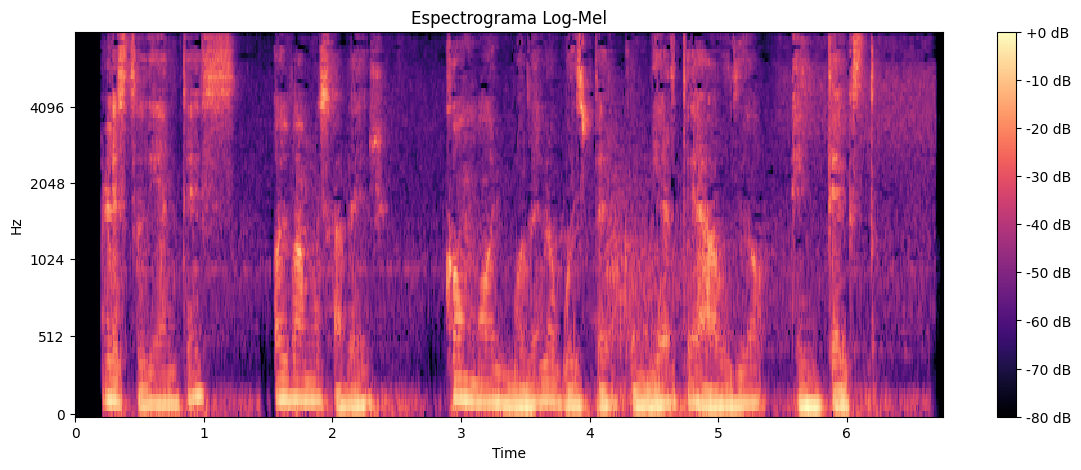

In [ ]:
# ACTIVIDAD 6:
# ESPECTROGRAMA LOG-MEL

mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=80,
    n_fft=400,
    hop_length=160
)

log_mel_spec = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    log_mel_spec,
    sr=sr,
    hop_length=160,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma Log-Mel")
plt.show()

In [ ]:
# ACTIVIDAD 7:
# TRANSCRIPCIÓN CON WHISPER

modelo_whisper = "openai/whisper-base"

processor = WhisperProcessor.from_pretrained(modelo_whisper)
model_whisper = WhisperForConditionalGeneration.from_pretrained(modelo_whisper).to(device)

model_whisper.eval()

inputs = processor(
    y,
    sampling_rate=sr,
    return_tensors="pt"
)

input_features = inputs.input_features.to(device)

forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="spanish",
    task="transcribe"
)

with torch.no_grad():
    predicted_ids = model_whisper.generate(
        input_features,
        forced_decoder_ids=forced_decoder_ids
    )

transcripcion = processor.batch_decode(
    predicted_ids,
    skip_special_tokens=True
)

print("Transcripción:")
print(transcripcion[0])

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

Transcripción:
 ¿Presudientes? Hoy vamos a ver cómo el modelo Wispers convierte a audio en texto.


## Reflexión 4

¿Whisper transcribió correctamente tu audio?

¿Qué errores cometió?

Respuesta:

In [ ]:
# ACTIVIDAD 8:
# AGREGAR RUIDO AL AUDIO

nivel_ruido = 0.02

ruido = np.random.normal(
    loc=0.0,
    scale=nivel_ruido,
    size=len(y)
)

y_ruidoso = y + ruido
y_ruidoso = y_ruidoso / np.max(np.abs(y_ruidoso))

print("Audio con ruido:")
display(Audio(y_ruidoso, rate=sr))

Audio con ruido:


In [ ]:
# ACTIVIDAD 9:
# TRANSCRIBIR AUDIO RUIDOSO

inputs_ruido = processor(
    y_ruidoso,
    sampling_rate=sr,
    return_tensors="pt"
)

input_features_ruido = inputs_ruido.input_features.to(device)

with torch.no_grad():
    predicted_ids_ruido = model_whisper.generate(
        input_features_ruido,
        forced_decoder_ids=forced_decoder_ids
    )

transcripcion_ruido = processor.batch_decode(
    predicted_ids_ruido,
    skip_special_tokens=True
)

print("Audio limpio:")
print(transcripcion[0])

print("\nAudio con ruido:")
print(transcripcion_ruido[0])

Audio limpio:
 ¿Presudientes? Hoy vamos a ver cómo el modelo Wispers convierte a audio en texto.

Audio con ruido:
 ¿Presudientes? Hoy vamos a ver cómo en un modelo buspejo, un vierte audido en texto.


## Reflexión 5

¿Qué cambió entre la transcripción limpia y la ruidosa?

¿Por qué el ruido puede afectar a Whisper?

Respuesta:

In [ ]:
# PARTE 4:
# MINI VISION TRANSFORMER
#
# En esta sección observarás cómo una imagen puede convertirse
# en una secuencia de patches.

In [ ]:
# ACTIVIDAD 10:
# CARGAR MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train:", X_train.shape)
print("Test:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28)
Test: (10000, 28, 28)


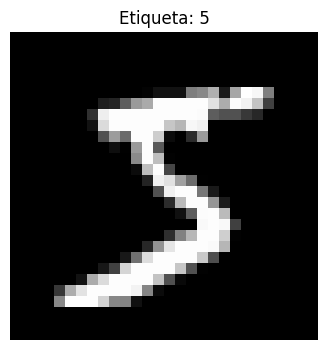

In [ ]:
# ACTIVIDAD 11:
# VISUALIZAR UNA IMAGEN

imagen = X_train[0]

plt.figure(figsize=(4, 4))
plt.imshow(imagen, cmap="gray")
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis("off")
plt.show()

In [ ]:
# ACTIVIDAD 12:
# DIVIDIR IMAGEN EN PATCHES

patch_size = 7

patches = []

for i in range(0, 28, patch_size):
    for j in range(0, 28, patch_size):
        patch = imagen[i:i+patch_size, j:j+patch_size]
        patches.append(patch)

patches = np.array(patches)

print("Número de patches:", len(patches))
print("Forma:", patches.shape)

Número de patches: 16
Forma: (16, 7, 7)


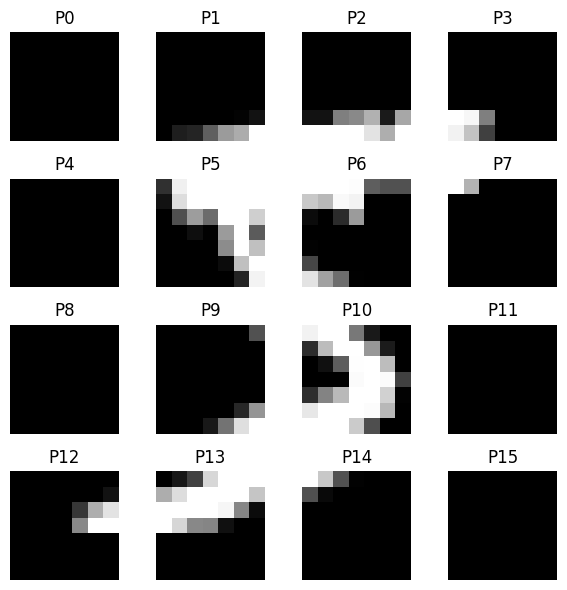

In [ ]:
# ACTIVIDAD 13:
# VISUALIZAR PATCHES

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for idx, ax in enumerate(axes.flat):
    ax.imshow(patches[idx], cmap="gray")
    ax.axis("off")
    ax.set_title(f"P{idx}")

plt.tight_layout()
plt.show()

In [ ]:
# ACTIVIDAD 14:
# FUNCIÓN PARA CREAR PATCHES EN TODO EL DATASET

def crear_patches(dataset, patch_size=7):
    imagenes_patches = []

    for imagen in dataset:
        patches = []

        for i in range(0, 28, patch_size):
            for j in range(0, 28, patch_size):
                patch = imagen[i:i+patch_size, j:j+patch_size]
                patch = patch.flatten()
                patches.append(patch)

        imagenes_patches.append(patches)

    return np.array(imagenes_patches)

X_train_patches = crear_patches(X_train[:5000])
X_test_patches = crear_patches(X_test[:1000])

y_train_small = y_train[:5000]
y_test_small = y_test[:1000]

print("Train patches:", X_train_patches.shape)
print("Test patches:", X_test_patches.shape)

Train patches: (5000, 16, 49)
Test patches: (1000, 16, 49)


In [ ]:
# ACTIVIDAD 15:
# MINI BLOQUE TRANSFORMER

def transformer_block(x):

    attention = MultiHeadAttention(
        num_heads=2,
        key_dim=32
    )(x, x)

    x = x + attention
    x = LayerNormalization()(x)

    ff = Dense(128, activation="relu")(x)
    ff = Dense(64)(ff)

    x = x + ff
    x = LayerNormalization()(x)

    return x

In [ ]:
# ACTIVIDAD 16:
# CONSTRUIR MINI ViT

inputs = Input(shape=(16, 49))

x = Dense(64)(inputs)

x = transformer_block(x)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(10, activation="softmax")(x)

modelo_vit = Model(inputs, outputs)

modelo_vit.compile(
    optimizer=Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_vit.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 49)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16, 64)    │      3,200 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 64)    │     16,640 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │        650 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,482 (162.04 KB)

 Trainable params: 41,482 (162.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ACTIVIDAD 17:
# ENTRENAR MINI ViT

historial = modelo_vit.fit(
    X_train_patches,
    y_train_small,
    validation_split=0.2,
    epochs=5,
    batch_size=128
)

In [ ]:
# ACTIVIDAD 18:
# EVALUAR MINI ViT

loss, acc = modelo_vit.evaluate(
    X_test_patches,
    y_test_small
)

print("Accuracy:", acc)

In [ ]:
# ACTIVIDAD 19:
# CURVAS DE ENTRENAMIENTO

plt.figure(figsize=(12, 5))
plt.plot(historial.history["accuracy"], label="train")
plt.plot(historial.history["val_accuracy"], label="validation")
plt.title("Accuracy Mini ViT")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Reflexión 6

¿Qué representa un patch?

¿Por qué un Vision Transformer necesita positional encoding?

¿Por qué ViT suele requerir más datos que una CNN?

Respuesta:

## Conclusión final

Responde:

1. ¿Qué tienen en común BERT, Whisper y ViT?

2. ¿Qué cambia entre texto, audio e imagen?

3. ¿Qué modelo te pareció más interesante y por qué?

4. Propón una aplicación real usando Transformers.

Respuesta: